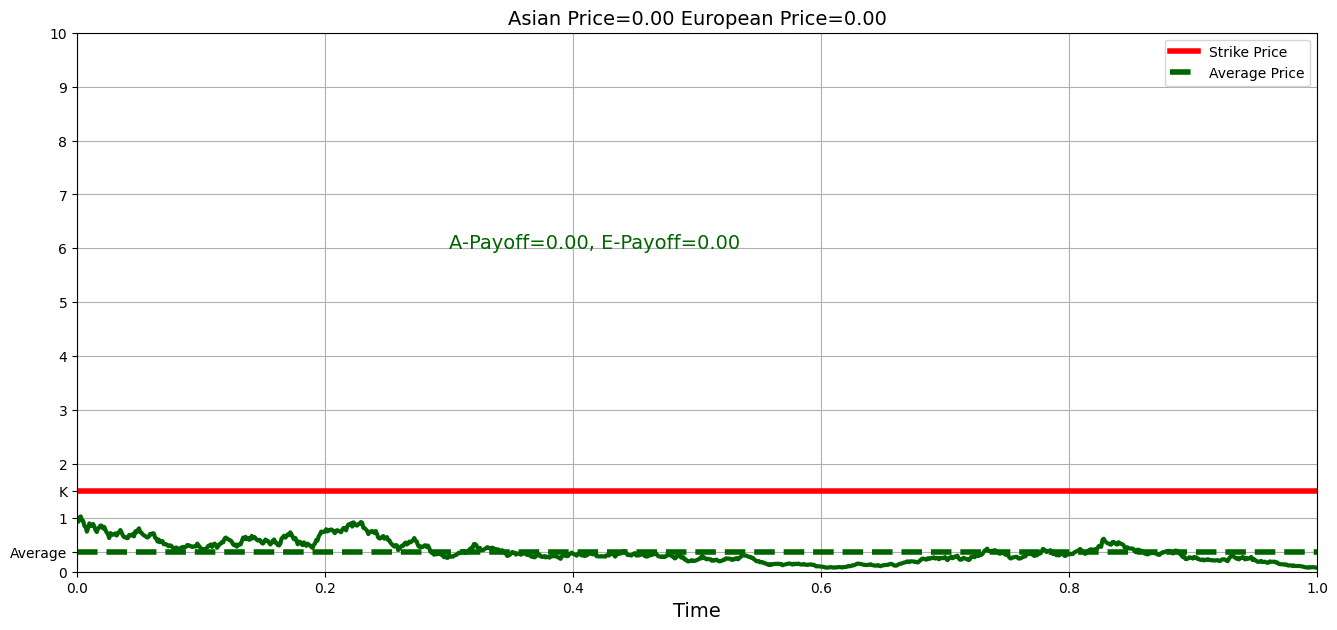

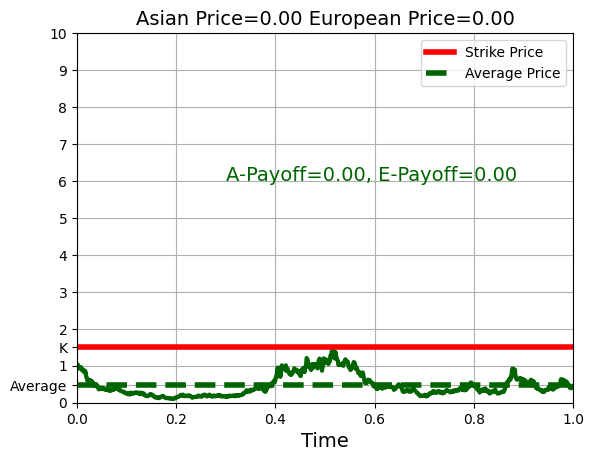

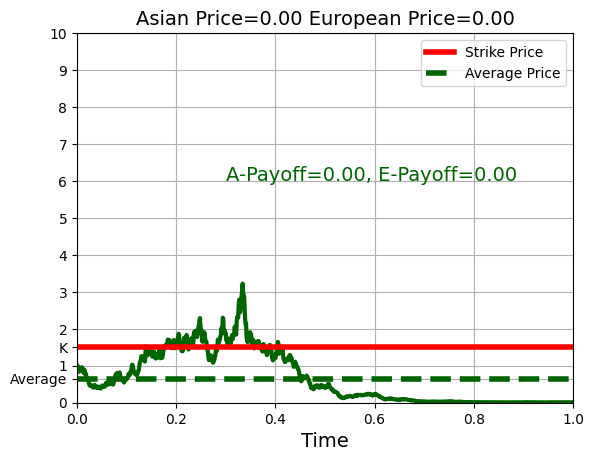

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from time import sleep

# Simulation parameters
nSim = 99999
N = 1000
t = np.arange(1, N + 1)
dt = 1.0/N
sigma = 2
r = 0.5
K = 1.5

# Initialize counters
european = 0
asian = 0

# Create figure
plt.figure(figsize=(16, 7))

for j in range(1, nSim + 1):
    # Generate price path
    random_walks = np.random.normal(0, np.sqrt(dt), N)
    S = np.exp(sigma * np.cumsum(random_walks) + r * t/N - sigma**2 * t/2/N)
    S = np.concatenate(([1], S))  # Add initial price of 1
    
    # Calculate average price
    A = np.sum([1] + list(S)) / (N + 1)
    
    # Update option values
    if S[-1] >= K:
        european += S[-1] - K
    if A >= K:
        asian += A - K
    
    # Determine color based on final vs average price
    color = 'darkred' if S[-1] > A else 'darkgreen'
    
    # Clear previous plot
    plt.clf()
    
    # Plot price path
    time_axis = np.arange(0, N + 1) / N
    plt.plot(time_axis, S, color=color, linewidth=3)
    
    # Plot strike price and average lines
    plt.axhline(y=K, color='red', linewidth=4, label='Strike Price')
    plt.axhline(y=A, color='darkgreen', linestyle='--', linewidth=4, label='Average Price')
    
    # Set plot limits and labels
    plt.ylim(0, np.exp(4*r))
    plt.xlim(0, 1)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('')
    
    # Add title with current prices
    title = f"Asian Price={asian/j:.2f} European Price={european/j:.2f}"
    plt.title(title, fontsize=14)
    
    # Add payoff text
    payoff_text = f"A-Payoff={max(A-K, 0):.2f}, E-Payoff={max(S[-1]-K, 0):.2f}"
    plt.text(0.3, 6, payoff_text, color=color, fontsize=14)
    
    # Customize y-axis ticks
    y_ticks = [0, K, A, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    y_labels = ['0', 'K', 'Average', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
    plt.yticks(y_ticks, y_labels)
    
    plt.grid(True)
    plt.legend()
    
    # Display plot
    plt.pause(0.1)
    
    # Pause if there's a payoff
    if S[-1] > K or A > K:
        input("Pause. Press Enter to continue...")

plt.show()